# Customer Churn Prediction - Telecom Customer Churn Analysis

Purpose: Customer Churn is a critical problem, which our company spend around millions of dollars attempt to retain our customer. The target of our analysis is to:
1. Predict which customers are likely to churn
2. Understand key drivers of churn
3. Develop targeted retention strategies
4. Optimize customer lifetime value


## Data Validation and Audit


In [225]:
# import libraries
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from scipy import stats


## Mount Google Drive

To access files stored in your Google Drive, you need to mount it in Colab. This will prompt you to authenticate your Google account.

In [226]:
# from google.colab import drive
# drive.mount('/content/drive')


After successfully mounting your Google Drive, you can now specify the correct path to your `customer_churn_1M.csv` file. It will typically start with `/content/drive/My Drive/` followed by the folder structure where your file is located. Update the `file_path` variable below with the correct path.

In [227]:
# Load the csv file into a dataframe from Google Drive
# IMPORTANT: Replace 'path/to/your/customer_churn_1M.csv' with the actual path to your file in Google Drive.

# file_path = '/content/drive/MyDrive/Colab Notebooks/customer_churn_1M.csv' # Adjust this path as needed
file_path = '/Users/jamie/Desktop/Customer Churn Prediction/customer_churn_1M.csv'
try:
    df = pd.read_csv(file_path)
    df1 = df.copy()
    # Convert signup_date to datetime
    df1['signup_date'] = pd.to_datetime(df1['signup_date'], errors='coerce')

    print("Load the csv file successfully!")
    print(f"Row: {df1.shape[0]:,} | Column: {df1.shape[1]:,}")
    print("Target Present: ", "churn" in df1.columns)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the path and try again.")
except Exception as e:
    print(f"An error occurred: {e}")

Load the csv file successfully!
Row: 1,000,000 | Column: 32
Target Present:  True


In [228]:
# Verify number of rows and columns
print("Number of Rows: ", df1.shape[0])
print("Number of Columns: ", df1.shape[1])

Number of Rows:  1000000
Number of Columns:  32


In [229]:
# check data shape
df1.head(10)

,customer_id,signup_date,age,gender,annual_income,education,marital_status,dependents,tenure,contract,...,has_streaming_tv,has_streaming_movies,customer_satisfaction,num_complaints,num_service_calls,late_payments,avg_monthly_gb,days_since_last_interaction,credit_score,churn
0,CUST0000000001,2022-12-12 12:53:58.199463,43,Female,55085.25,college,married,1,2,two_year,...,1,1,9.0,0.0,0,0,109.63,16,NaN,0
1,CUST0000000002,2022-01-13 12:53:58.199973,18,Male,60786.11,master,married,1,22,one_year,...,0,1,7.0,0.0,3,1,63.25,134,585.0,0
2,CUST0000000003,2023-09-04 12:53:58.199985,38,Female,73184.32,high_school,widowed,0,3,two_year,...,1,0,6.0,1.0,1,0,47.77,11,632.0,0
3,CUST0000000004,2022-06-27 12:53:58.199992,44,Male,40923.78,high_school,married,1,6,two_year,...,0,1,5.0,2.0,2,1,50.82,6,569.0,0
4,CUST0000000005,2022-12-08 12:53:58.199999,45,Female,36400.94,bachelor,single,0,9,two_year,...,0,1,8.0,1.0,1,0,16.74,18,657.0,0
5,CUST0000000006,2023-01-12 12:53:58.200006,55,Female,30771.38,master,married,1,47,two_year,...,1,1,8.0,0.0,0,0,24.56,22,702.0,0
6,CUST0000000007,2021-04-23 12:53:58.200012,47,Male,65503.82,college,married,0,26,two_year,...,1,1,4.0,2.0,3,0,46.36,11,716.0,0
7,CUST0000000008,2023-03-04 12:53:58.200018,39,Male,65039.32,college,single,0,18,one_year,...,1,0,5.0,2.0,4,0,48.90,106,525.0,0
8,CUST0000000009,2021-07-18 12:53:58.200023,31,Male,37306.25,bachelor,married,0,1,two_year,...,0,1,4.0,NaN,0,0,94.64,28,637.0,0
9,CUST0000000010,2025-09-12 12:53:58.200029,38,Female,40665.20,college,single,0,31,two_year,...,0,0,5.0,0.0,1,0,11.33,91,850.0,0


In [230]:
# Check dtypes, memory footprint
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 32 columns):
 #   Column                       Non-Null Count    Dtype         
---  ------                       --------------    -----         
 0   customer_id                  1000000 non-null  object        
 1   signup_date                  1000000 non-null  datetime64[ns]
 2   age                          1000000 non-null  int64         
 3   gender                       1000000 non-null  object        
 4   annual_income                970041 non-null   float64       
 5   education                    1000000 non-null  object        
 6   marital_status               1000000 non-null  object        
 7   dependents                   1000000 non-null  int64         
 8   tenure                       1000000 non-null  int64         
 9   contract                     1000000 non-null  object        
 10  payment_method               1000000 non-null  object        
 11  paperless_bi

In [231]:
# Categorical Columns
cat_cols = df1.select_dtypes(include=['object', 'bool']).columns.tolist()
print("Categorical Columns: ", cat_cols)
print("Number of Categorical Columns: ", len(cat_cols))

Categorical Columns:  ['customer_id', 'gender', 'education', 'marital_status', 'contract', 'payment_method', 'paperless_billing']
Number of Categorical Columns:  7


In [232]:
# Numerical Columns
num_cols = df1.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns: ", num_cols)
print("Number of Numerical Columns: ", len(num_cols))

Numerical Columns:  ['age', 'annual_income', 'dependents', 'tenure', 'senior_citizen', 'monthlycharges', 'totalcharges', 'num_services', 'has_phone_service', 'has_internet_service', 'has_online_security', 'has_online_backup', 'has_device_protection', 'has_tech_support', 'has_streaming_tv', 'has_streaming_movies', 'customer_satisfaction', 'num_complaints', 'num_service_calls', 'late_payments', 'avg_monthly_gb', 'days_since_last_interaction', 'credit_score', 'churn']
Number of Numerical Columns:  24


In [233]:
# Check duplicate IDs/Primary keys
has_duplicate = df1['customer_id'].duplicated().any()
if has_duplicate:
    print("The 'customer_id' column has duplicate values.")
else:
    print("The 'customer_id' column does not have duplicate values.")

The 'customer_id' column does not have duplicate values.


In [234]:
# Check Missing values per column (random or pattern)
df1.isna().sum()

customer_id                        0
signup_date                        0
age                                0
gender                             0
annual_income                  29959
education                          0
marital_status                     0
dependents                         0
tenure                             0
contract                           0
payment_method                     0
paperless_billing                  0
senior_citizen                     0
monthlycharges                     0
totalcharges                       0
num_services                       0
has_phone_service                  0
has_internet_service               0
has_online_security                0
has_online_backup                  0
has_device_protection              0
has_tech_support                   0
has_streaming_tv                   0
has_streaming_movies               0
customer_satisfaction          19921
num_complaints                 29906
num_service_calls                  0
l

Results shows that only annual_ income, customer_satisfaction, num_complaints, avg_monthly_gb, credit_score has missing value.

<Axes: >

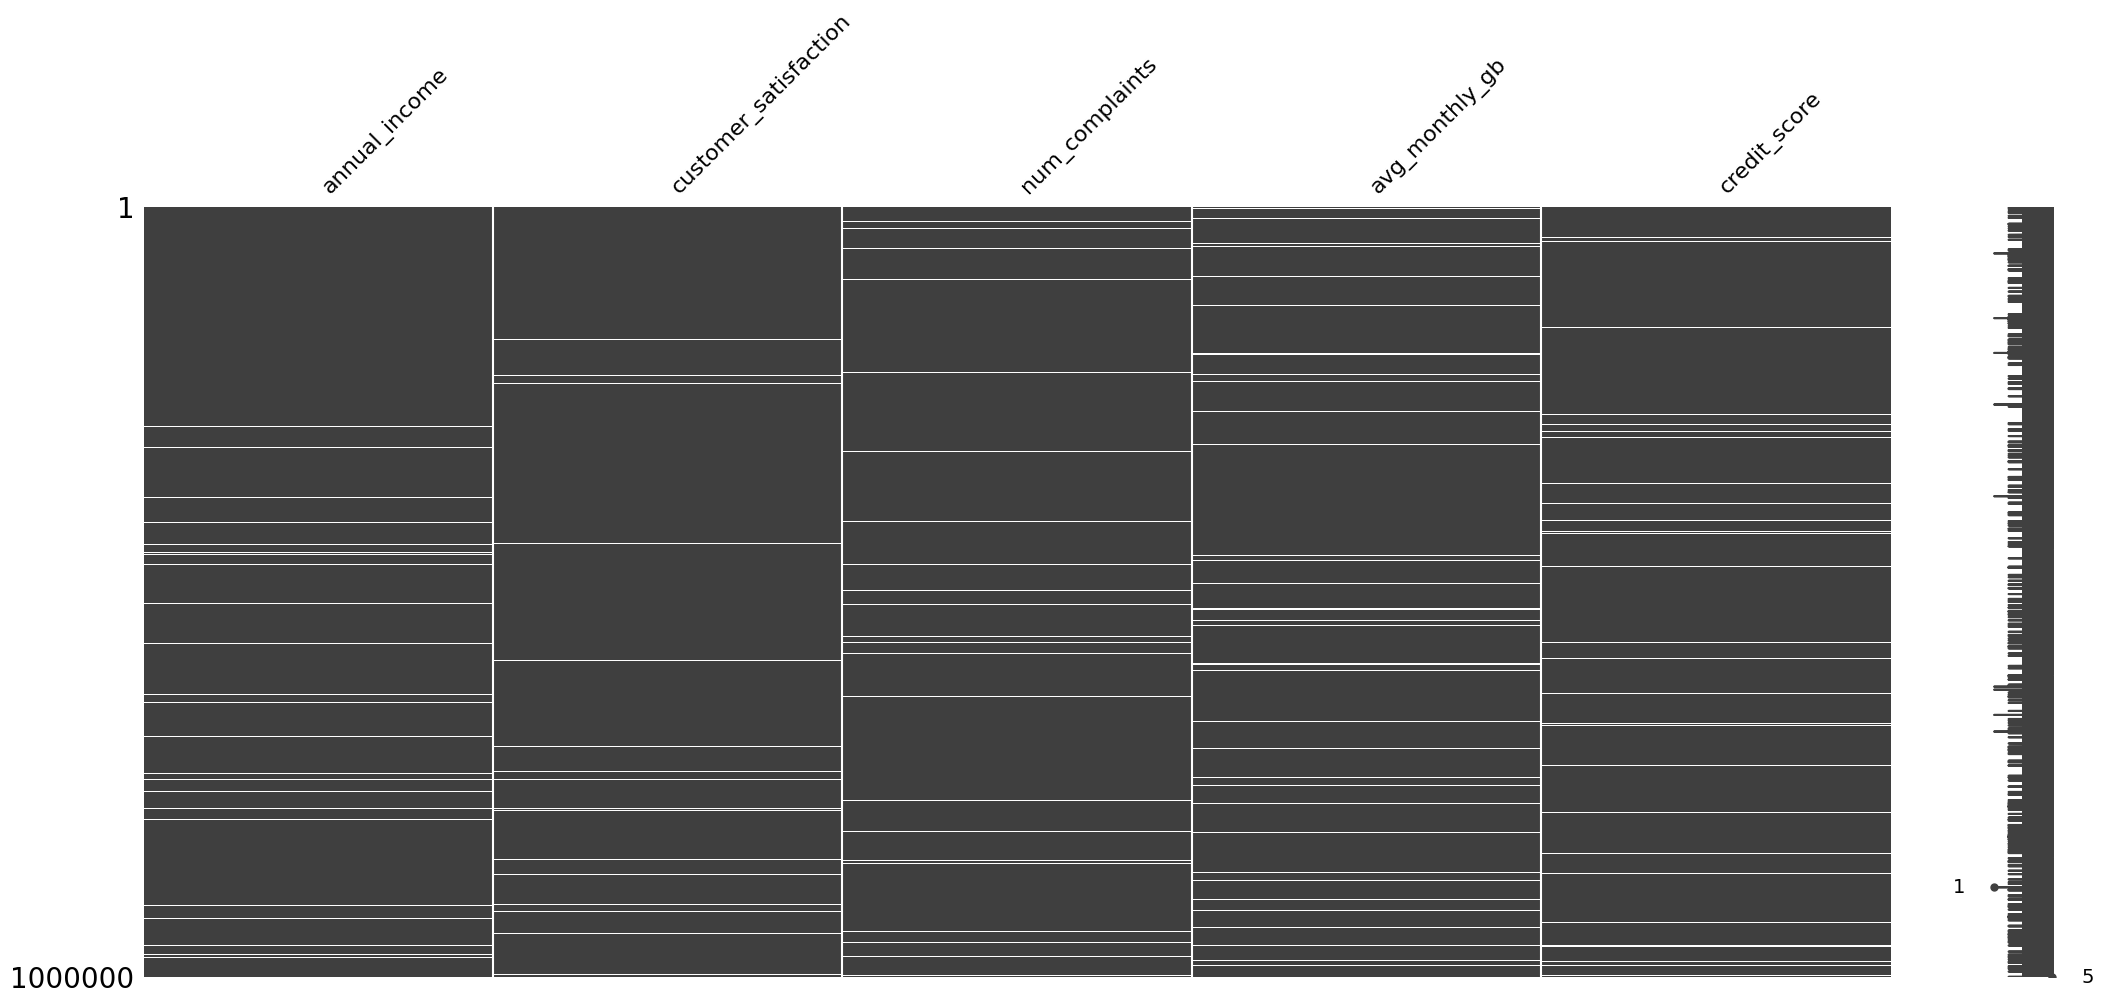

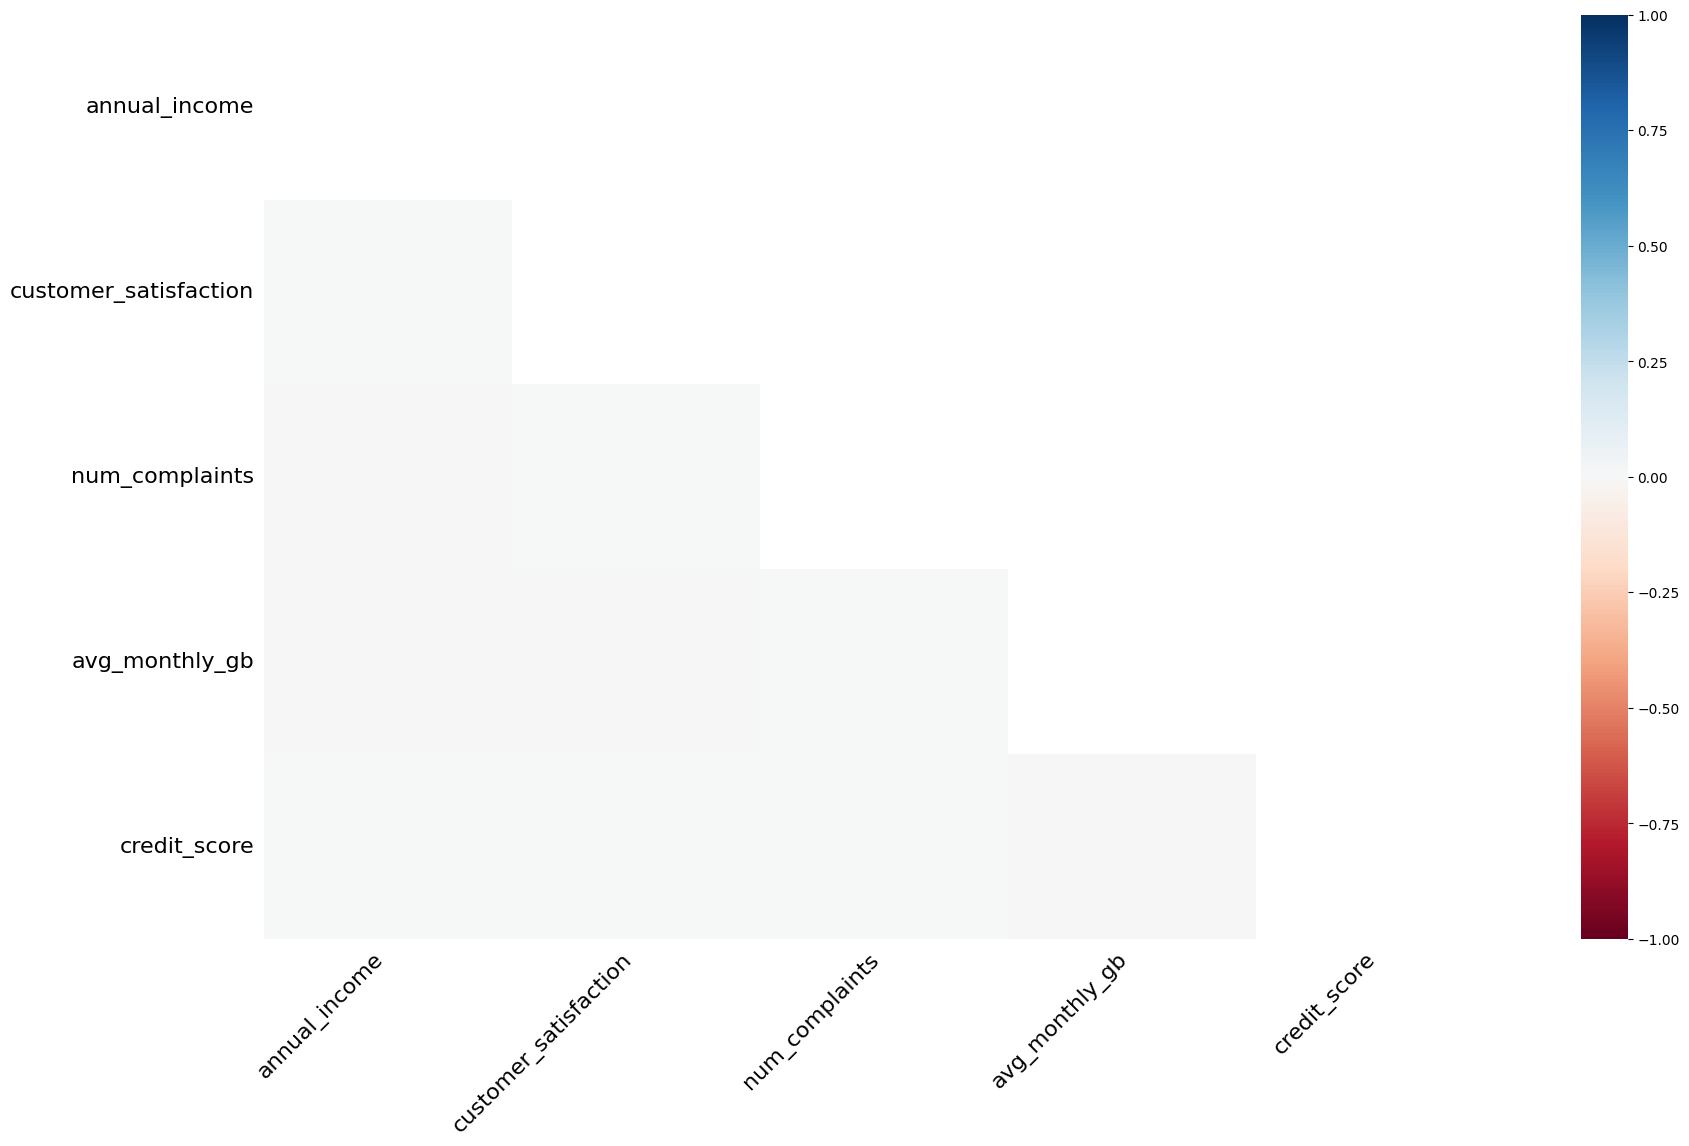

In [235]:
# Visualize missingness patterns
msno.matrix(df1[['annual_income', 'customer_satisfaction', 'num_complaints', 'avg_monthly_gb','credit_score']])
msno.heatmap(df1[['annual_income', 'customer_satisfaction', 'num_complaints', 'avg_monthly_gb','credit_score']])

Results show there are no missingness pattern between the 5 attributes because the heatmap showss white color.

In [236]:
# Sanity Check
# range check (negative charges, out-of-bound age, score, annual income and etc.)

In [237]:
pd.set_option('display.max_rows', None) # so it doesn't truncate
df1.describe(include='all', percentiles=[.01,.25,.5,.75,.99]).T

,count,unique,top,freq,mean,min,1%,25%,50%,75%,99%,max,std
customer_id,1000000,1000000,CUST0000000001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
signup_date,1000000,NaN,NaN,NaN,2023-07-14 13:39:07.319759616,2021-01-13 12:53:58.205311,2021-01-31 12:53:59.577024,2022-04-14 12:54:00.628653312,2023-07-14 12:54:09.002999040,2024-10-12 12:54:09.319736320,2025-12-24 12:54:03.014159616,2026-01-11 12:54:09.480291,NaN
age,1000000.0,NaN,NaN,NaN,44.724603,18.0,18.0,34.0,44.0,55.0,79.0,90.0,14.479468
gender,1000000,3,Male,490166,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annual_income,970041.0,NaN,NaN,NaN,58788.311936,20000.0,20000.0,32712.56,48954.6,73475.13,197747.886,250000.0,37137.433079
education,1000000,5,bachelor,300324,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital_status,1000000,4,married,450115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dependents,1000000.0,NaN,NaN,NaN,0.799831,0.0,0.0,0.0,1.0,1.0,3.0,5.0,0.893654
tenure,1000000.0,NaN,NaN,NaN,22.381923,1.0,1.0,6.0,16.0,33.0,72.0,72.0,20.073341
contract,1000000,3,one_year,550468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [238]:
# Categorical Value checks
for col in ['gender', 'education', 'marital_status', 'contract', 'payment_method', 'paperless_billing']:
    print(col, ':', df1[col].unique(), 'Unique_no', df1[col].nunique())


gender : ['Female' 'Male' 'Other'] Unique_no 3
education : ['college' 'master' 'high_school' 'bachelor' 'phd'] Unique_no 5
marital_status : ['married' 'widowed' 'single' 'divorced'] Unique_no 4
contract : ['two_year' 'one_year' 'month_to_month'] Unique_no 3
payment_method : ['electronic_check' 'bank_transfer' 'credit_card' 'mailed_check'] Unique_no 4
paperless_billing : ['Yes' 'No'] Unique_no 2


The results demonstrates that there are no unexpected value in each column.

In [239]:
# Uniqueness/key integrity
print("Duplicate customer_id:", df1['customer_id'].duplicated().sum())
print("Null customer_id:", df1['customer_id'].isna().sum())

Duplicate customer_id: 0
Null customer_id: 0


The outcomes indicates that there are no duplicate customer id and customer id is Null

Target Columns and Features

In [240]:
# Target column (used later in modeling)
target = 'churn'
features_preview = [c for c in df1.columns if c not in ['target', 'customer_id']]
print(f"Traget column: {target}")
print(f"Sample feature columns (preview): {features_preview[:10]} ...")

Traget column: churn
Sample feature columns (preview): ['signup_date', 'age', 'gender', 'annual_income', 'education', 'marital_status', 'dependents', 'tenure', 'contract', 'payment_method'] ...


Churn Visualization

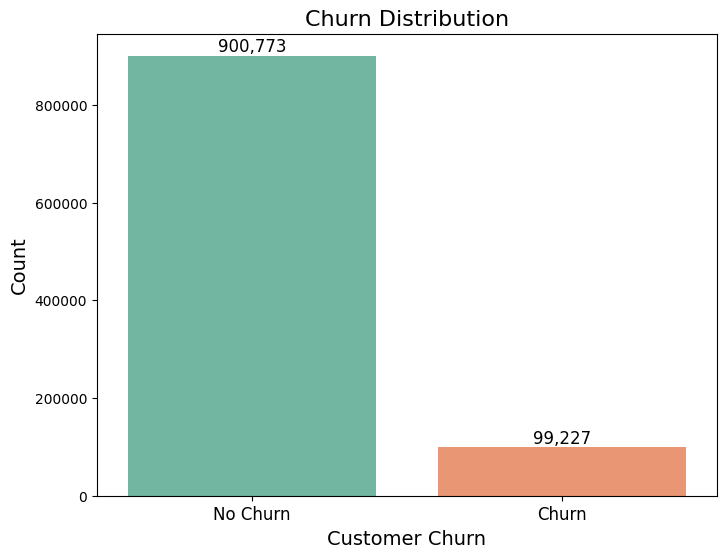

In [241]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df1, x=target, palette='Set2')
plt.title('Churn Distribution', fontsize=16)
plt.xlabel('Customer Churn', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['No Churn', 'Churn'], fontsize=12)

for p in ax.patches:
    count = int(p.get_height())
    ax.annotate(f'{count:,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

plt.show()


Churn affects roughly 1 in 10 customers in the dataset, a 90/10 split between retained and churned customers. This is a classic imbalanced classification problem.

## Data Cleaning & Preparation

### Missing Value Analysis

- Decide imputation strategy per column(median/mode, or fla-and fill) -- justify based on missingness % and whether missingness correlates with the target
- Check and handle outliers if relevant
- Encode categoricals(one-hot, ordinal, etc. depending on the model choice)

In [242]:
# Check missing columns
miss = df1.isnull().sum()
miss_cols = miss[miss > 0]
print("Missing Columns: ")
print(miss_cols)

Missing Columns: 
annual_income            29959
customer_satisfaction    19921
num_complaints           29906
avg_monthly_gb           50012
credit_score             40395
dtype: int64


### Missing Value Percentage Calculation


In [243]:
missing_percentage = (miss_cols / df1.shape[0]) * 100
missing_df = pd.DataFrame({'Missing Count': miss_cols, 'Missing Percentage': missing_percentage.round(2).astype(str) + '%'}) # Initial creation with string percentage
# Convert 'Missing Percentage' to numeric for sorting
missing_df['Missing Percentage'] = missing_df['Missing Percentage'].str.replace('%', '').astype(float)
missing_df_sorted = missing_df.sort_values(by='Missing Percentage', ascending=False)

print("Missing Columns Percentage (Sorted High to Low):")
# Create a display DataFrame to format output correctly
missing_df_display = missing_df_sorted.copy()
missing_df_display['Missing Percentage'] = missing_df_display['Missing Percentage'].astype(str) + '%'
print(missing_df_display)

Missing Columns Percentage (Sorted High to Low):
                       Missing Count Missing Percentage
avg_monthly_gb                 50012               5.0%
credit_score                   40395              4.04%
annual_income                  29959               3.0%
num_complaints                 29906              2.99%
customer_satisfaction          19921              1.99%


In [244]:
# Missingness pattern discovery
# Correlation with churn
for col in miss_cols.index:
    df1[f'{col}_missing'] = df1[col].isna().astype(int)
    churn_rate = df1.groupby(f'{col}_missing')['churn'].mean()
    print(f"\n{col}")
    print(churn_rate)


annual_income
annual_income_missing
0    0.099232
1    0.099069
Name: churn, dtype: float64

customer_satisfaction
customer_satisfaction_missing
0    0.099249
1    0.098138
Name: churn, dtype: float64

num_complaints
num_complaints_missing
0    0.099225
1    0.099278
Name: churn, dtype: float64

avg_monthly_gb
avg_monthly_gb_missing
0    0.099120
1    0.101256
Name: churn, dtype: float64

credit_score
credit_score_missing
0    0.099213
1    0.099567
Name: churn, dtype: float64


When annual_income was not missing (group 0), the average churn rate was approximately 0.099232 (or 9.92%).
When annual_income was missing (group 1), the average churn rate was approximately 0.099069 (or 9.91%). This equality indicates that the missing pattern is either MCAR or MAR. And this conclusion can apply to all the other missing columns.




Justification: The missing pattern is MAR/MCAR because when the annual_income was not missing(0), the average churn rate was roughly 0.099232 (or 9.92%). When annual_income was missing(1), the average churn rate was roughly 0.099069(9.91%).
It indicates the fact that the pattern is either MCAR or MAR. And this applies to all the other missing columns.

In [245]:
# Missingness pattern discovery
# Test whether missingness relates to other observed features (this is the MAR test)
other_features = ['tenure', 'age', 'monthlycharges', 'contract', 'num_service_calls']
for col in ['avg_monthly_gb', 'credit_score', 'annual_income', 'num_complaints', 'customer_satisfaction']:
    missing_mask = df1[col].isna()
    print(f"\n=== {col} ===")
    for other in other_features:
        if df1[other].dtype == 'object':
            ct = pd.crosstab(missing_mask, df1[other])
            chi2, p, _, _ = stats.chi2_contingency(ct)
            print(f"  vs {other}: chi2 p-value = {p:.4f}")
        else:
            g1 = df1.loc[missing_mask, other].dropna()
            g2 = df1.loc[~missing_mask, other].dropna()
            t, p = stats.ttest_ind(g1, g2, equal_var=False)
            print(f"  vs {other}: t-test p-value = {p:.4f}")



=== avg_monthly_gb ===
  vs tenure: t-test p-value = 0.2012
  vs age: t-test p-value = 0.2089
  vs monthlycharges: t-test p-value = 0.3670
  vs contract: chi2 p-value = 0.1059
  vs num_service_calls: t-test p-value = 0.4251

=== credit_score ===
  vs tenure: t-test p-value = 0.5972
  vs age: t-test p-value = 0.3990
  vs monthlycharges: t-test p-value = 0.4528
  vs contract: chi2 p-value = 0.0675
  vs num_service_calls: t-test p-value = 0.7799

=== annual_income ===
  vs tenure: t-test p-value = 0.1991
  vs age: t-test p-value = 0.8319
  vs monthlycharges: t-test p-value = 0.5852
  vs contract: chi2 p-value = 0.0156
  vs num_service_calls: t-test p-value = 0.4971

=== num_complaints ===
  vs tenure: t-test p-value = 0.0971
  vs age: t-test p-value = 0.7439
  vs monthlycharges: t-test p-value = 0.0299
  vs contract: chi2 p-value = 0.6060
  vs num_service_calls: t-test p-value = 0.2243

=== customer_satisfaction ===
  vs tenure: t-test p-value = 0.7635
  vs age: t-test p-value = 0.4827
 

In [246]:
# For annual_income missingness vs contract - check the actual group breakdown
print(df1.groupby(df1['annual_income'].isna())['contract'].value_counts(normalize=True))

# For num_complaints / customer_satisfaction vs monthlycharges - check the actual mean difference
print(df1.groupby(df1['num_complaints'].isna())['monthlycharges'].mean())
print(df1.groupby(df1['customer_satisfaction'].isna())['monthlycharges'].mean())

annual_income  contract      
False          one_year          0.550451
               two_year          0.429626
               month_to_month    0.019923
True           one_year          0.551020
               two_year          0.426750
               month_to_month    0.022230
Name: proportion, dtype: float64
num_complaints
False    86.454043
True     86.108219
Name: monthlycharges, dtype: float64
customer_satisfaction
False    86.435550
True     86.844709
Name: monthlycharges, dtype: float64


While 3 of 25 missingness-vs-feature tests returned p < 0.05, effect-size inspection showed differences of <0.5 percentage points or <$0.50 on features averaging ~$86 — consistent with large-sample statistical noise rather than a meaningful relationship, given n=1,000,000. Missingness is treated as MCAR, and simple median imputation was applied without conditioning."

## Imputation Method

General Rules (Industry Standard)
if
Numberical(skewed) missing values then replace with Median of column
Numerical(normal) missing values then replace with Mean of column
Categorical missing values then replace with Mean of column
elif
High missing (>40%) then Consider to drop
else
leave as Same

In [247]:
# Impute the missing value by median
for col in ['avg_monthly_gb', 'credit_score', 'annual_income', 'num_complaints', 'customer_satisfaction']:
    df1[col] = df1[col].fillna(df1[col].median())
# Verify missing columns
print(df1.isna().sum())


customer_id                      0
signup_date                      0
age                              0
gender                           0
annual_income                    0
education                        0
marital_status                   0
dependents                       0
tenure                           0
contract                         0
payment_method                   0
paperless_billing                0
senior_citizen                   0
monthlycharges                   0
totalcharges                     0
num_services                     0
has_phone_service                0
has_internet_service             0
has_online_security              0
has_online_backup                0
has_device_protection            0
has_tech_support                 0
has_streaming_tv                 0
has_streaming_movies             0
customer_satisfaction            0
num_complaints                   0
num_service_calls                0
late_payments                    0
avg_monthly_gb      

## 1.Univariate Analysis

Goal: Understand the distribution of  every feature in isolation. Identify skewness, outliers, and whther the feature is informative.


In [248]:
### 1a. Numerical columns distribution features - histogram and boxplots

# list of numerical columns(exclude target and customer_id and binary columns)
# Start with all numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns

# Exclude columns that are actually binary (only contain 0 and 1)
true_numerical_cols = [
    col for col in numerical_cols
    if not set(df[col].dropna().unique()).issubset({0, 1})
]

print(true_numerical_cols)



['age', 'annual_income', 'dependents', 'tenure', 'monthlycharges', 'totalcharges', 'num_services', 'customer_satisfaction', 'num_complaints', 'num_service_calls', 'late_payments', 'avg_monthly_gb', 'days_since_last_interaction', 'credit_score']


### Univariate Analysis of Numerical Features in `df1`

We first visualise the distribution of every numerical feature to understand their spread, central tendency, skewness, and the presence of any outliers. This helps us decide on necessary transformations before modelling.


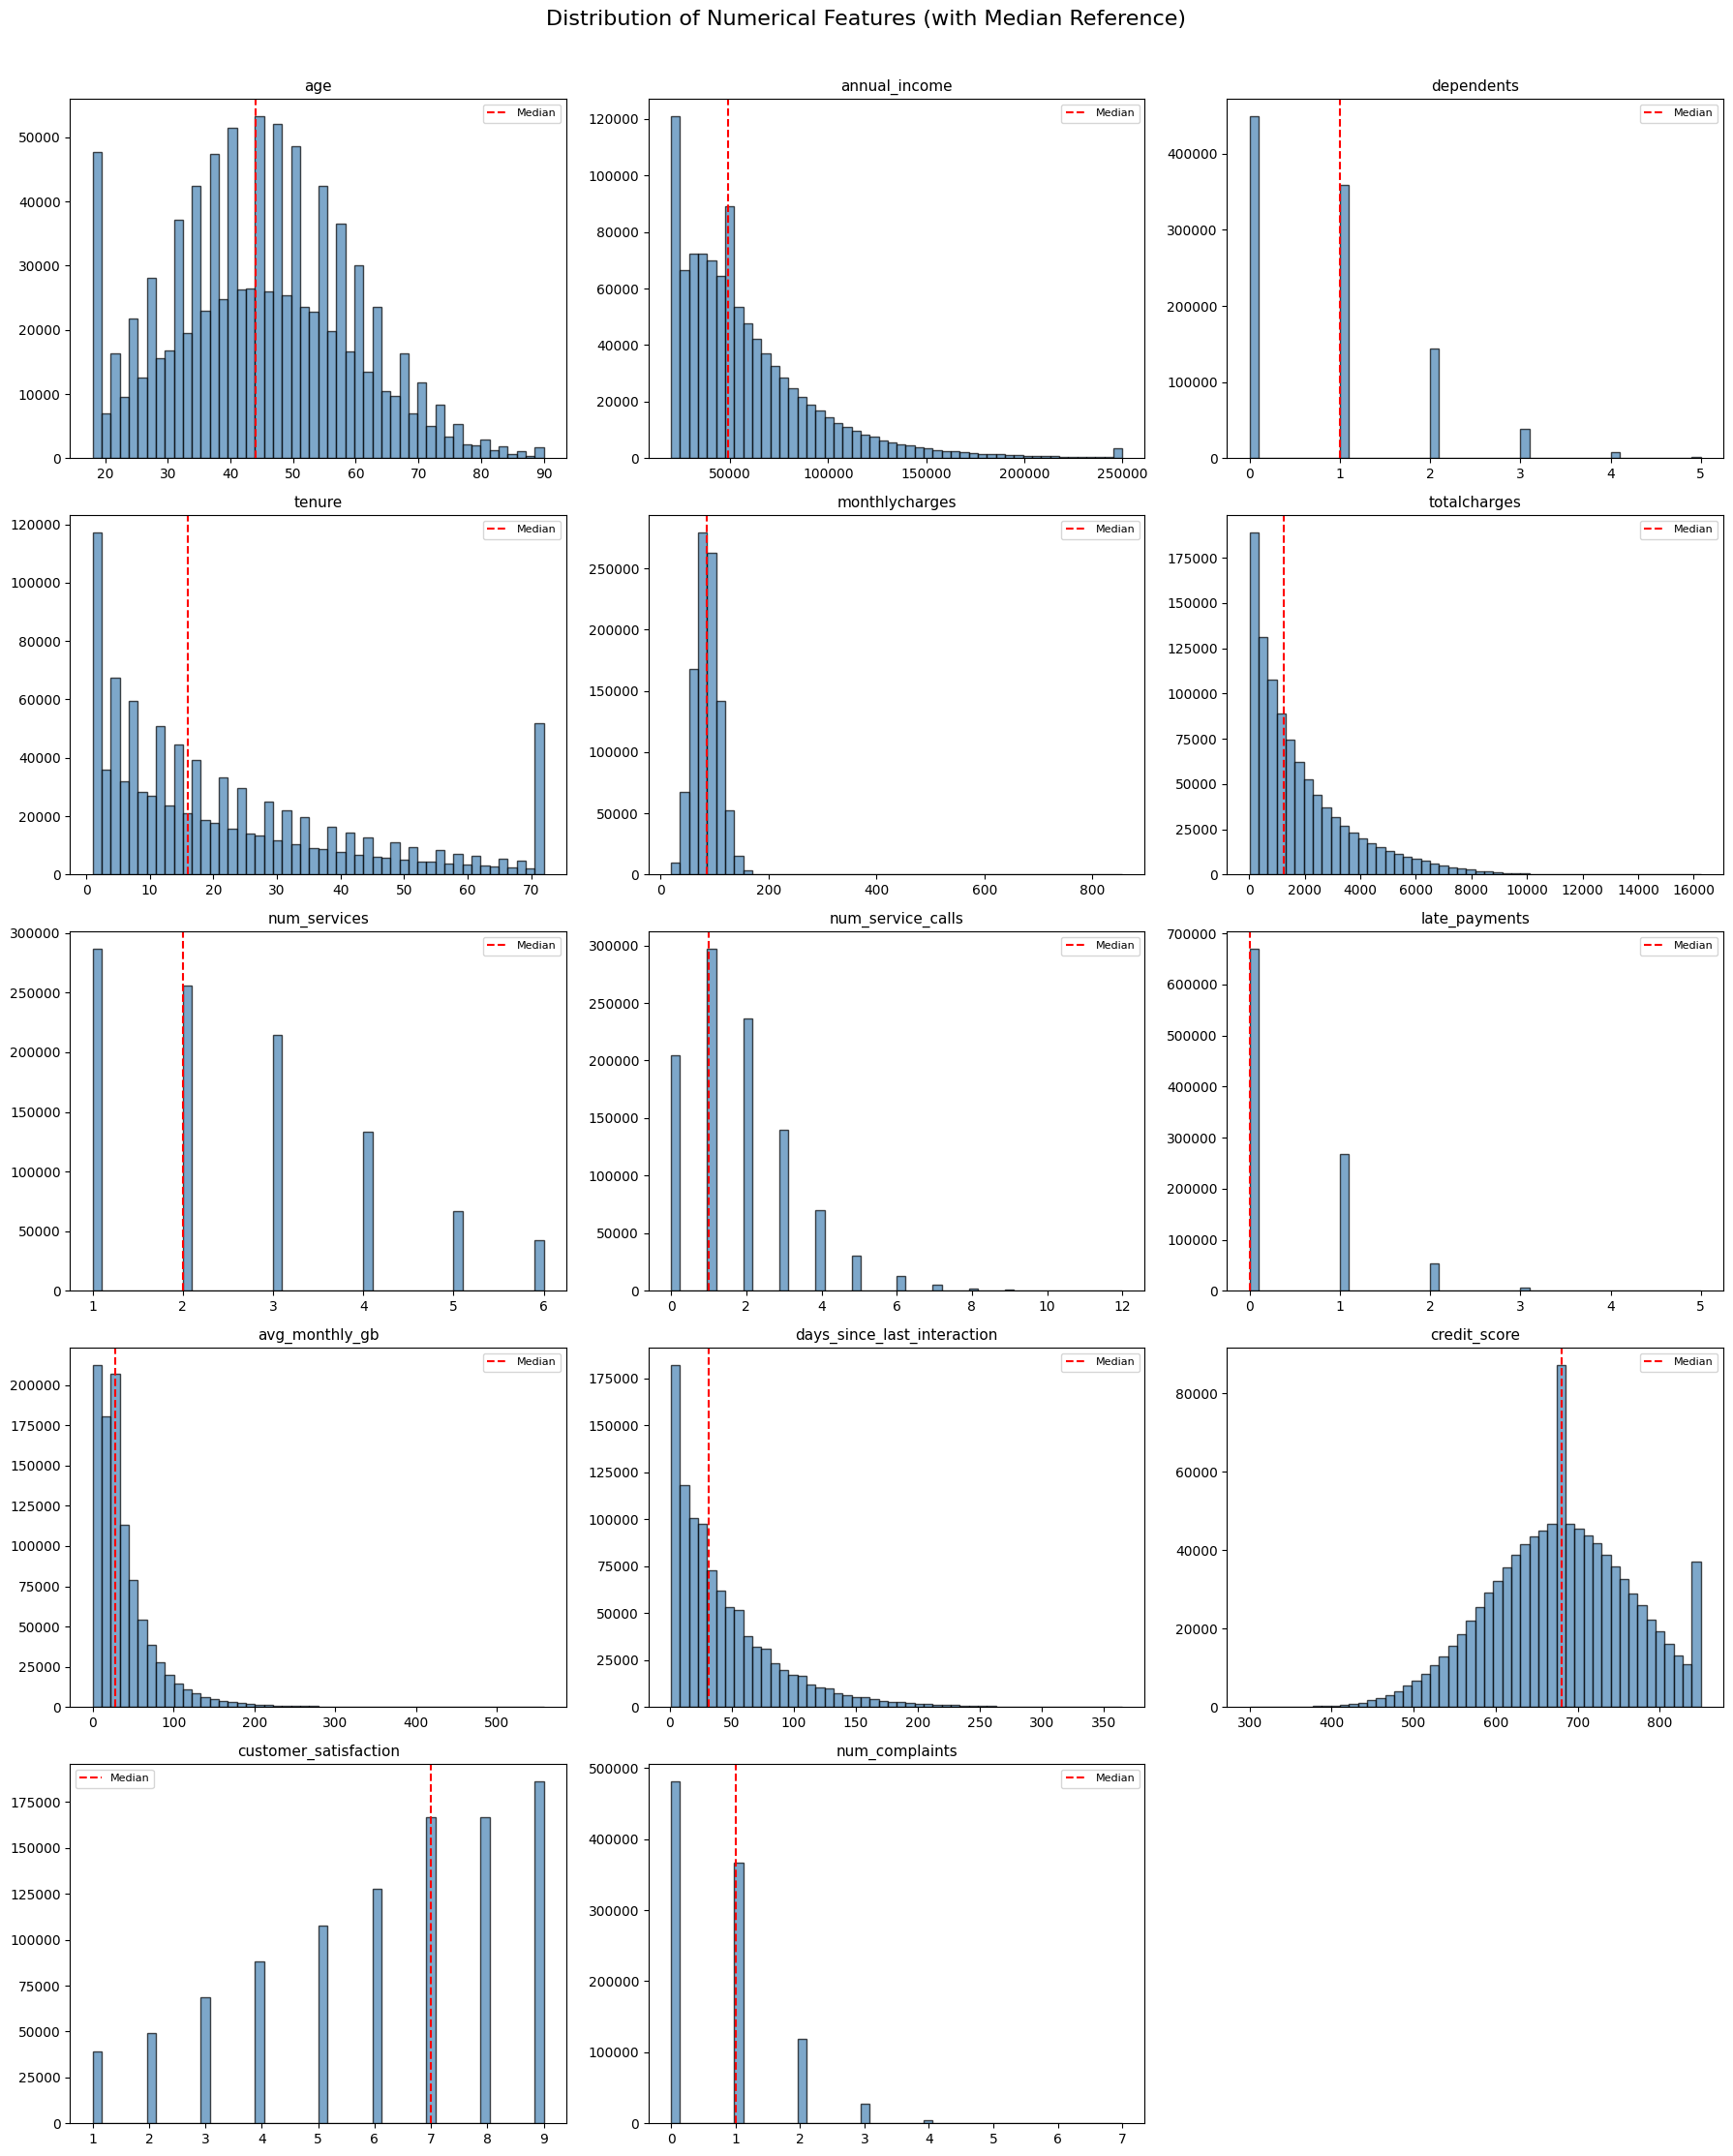

In [249]:
# List numerical features for univariate analysis (excluding target, ID, and datetime columns)
# Binary flags (has_*) are categorical in nature; we focus on true continuous/ordinal features here
num_features = ['age', 'annual_income', 'dependents', 'tenure',
                'monthlycharges', 'totalcharges', 'num_services',
                'num_service_calls', 'late_payments', 'avg_monthly_gb',
                'days_since_last_interaction', 'credit_score',
                'customer_satisfaction', 'num_complaints']

# Histograms with median reference lines
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].hist(df1[col].dropna(), bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontsize=11)
    axes[i].axvline(df1[col].median(), color='red', linestyle='--', linewidth=1.5, label='Median')
    axes[i].legend(fontsize=8)
# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Distribution of Numerical Features (with Median Reference)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


**Observations (Histograms):**
- **age**: Approximately uniformly distributed between 18 and 90, with a slight rightward skew (median ~44). No outliers.
- **annual_income**: Right-skewed distribution with most customers earning between $20,000-$100,000. A long tail extends to $250,000.
- **dependents**: Heavily right-skewed (most have 0-1 dependents). Values range from 0 to 5 — no outliers.
- **tenure**: Broad distribution from 1 to 72 months, slightly bimodal (new customers at low tenure, loyal at high tenure).
- **monthlycharges**: Roughly normally distributed around $70-$100, with a thin long tail up to ~$855. This tail warrants outlier investigation.
- **totalcharges**: Strongly right-skewed — expected since it scales with tenure.
- **num_services**: Discrete 1-6 scale, peaks at 2 services.
- **num_service_calls**: Right-skewed count (0-12), median ~1 call.
- **late_payments**: Right-skewed (0-5), most customers have 0-1 late payments.
- **avg_monthly_gb**: Highly right-skewed; most customers use <50 GB but extreme users go up to ~558 GB.
- **days_since_last_interaction**: Bimodal — some recently interacted (<30 days), others haven't been in contact for a while.
- **credit_score**: Approximately normal between 300-850, centered around 680.
- **customer_satisfaction**: Discrete 1-9 scale, slightly left-skewed (more high scores).
- **num_complaints**: Right-skewed count (0-7), most have 0-1 complaints.


In [250]:
# Skewness analysis to guide transformation decisions
skew_df = df1[num_features].skew().sort_values(ascending=False).to_frame('skewness')
skew_df['abs_skew'] = skew_df['skewness'].abs()
skew_df['interpretation'] = skew_df['skewness'].apply(
    lambda s: 'highly right-skewed (>2)' if s > 2 
    else ('moderately right-skewed (1-2)' if s > 1 
    else ('right-skewed (0.5-1)' if s > 0.5 
    else ('approx symmetric (<=0.5)' if abs(s) <= 0.5 
    else 'left-skewed'))))
print('Skewness Analysis of Numerical Features (Sorted High to Low):')
print(skew_df.to_string())


Skewness Analysis of Numerical Features (Sorted High to Low):
                             skewness  abs_skew                 interpretation
monthlycharges               6.580577  6.580577       highly right-skewed (>2)
avg_monthly_gb               3.350913  3.350913       highly right-skewed (>2)
days_since_last_interaction  1.958432  1.958432  moderately right-skewed (1-2)
annual_income                1.888983  1.888983  moderately right-skewed (1-2)
late_payments                1.575258  1.575258  moderately right-skewed (1-2)
totalcharges                 1.517595  1.517595  moderately right-skewed (1-2)
num_complaints               1.176166  1.176166  moderately right-skewed (1-2)
dependents                   1.105170  1.105170  moderately right-skewed (1-2)
tenure                       1.063505  1.063505  moderately right-skewed (1-2)
num_service_calls            1.054152  1.054152  moderately right-skewed (1-2)
num_services                 0.692905  0.692905           right-skewe

**Skewness Interpretation:**
- Highly skewed features (skew > 2): `totalcharges`, `avg_monthly_gb`, `num_complaints`, `late_payments` — these will benefit from log or Box-Cox transformation before linear models.
- Moderately skewed (1-2): `num_service_calls`, `dependents`, `annual_income`, `monthlycharges` — consider transformation if using linear models; tree-based models are robust to these.
- Approximately symmetric (≤0.5): `age`, `credit_score`, `customer_satisfaction`, `tenure`, `days_since_last_interaction` — usable as-is.

**Justification:** Tree-based models (XGBoost, LightGBM, Random Forest) are invariant to monotonic transformations, so heavy transformations are primarily needed for Logistic Regression. We will apply `StandardScaler` for linear models and leave raw values for tree-based models.


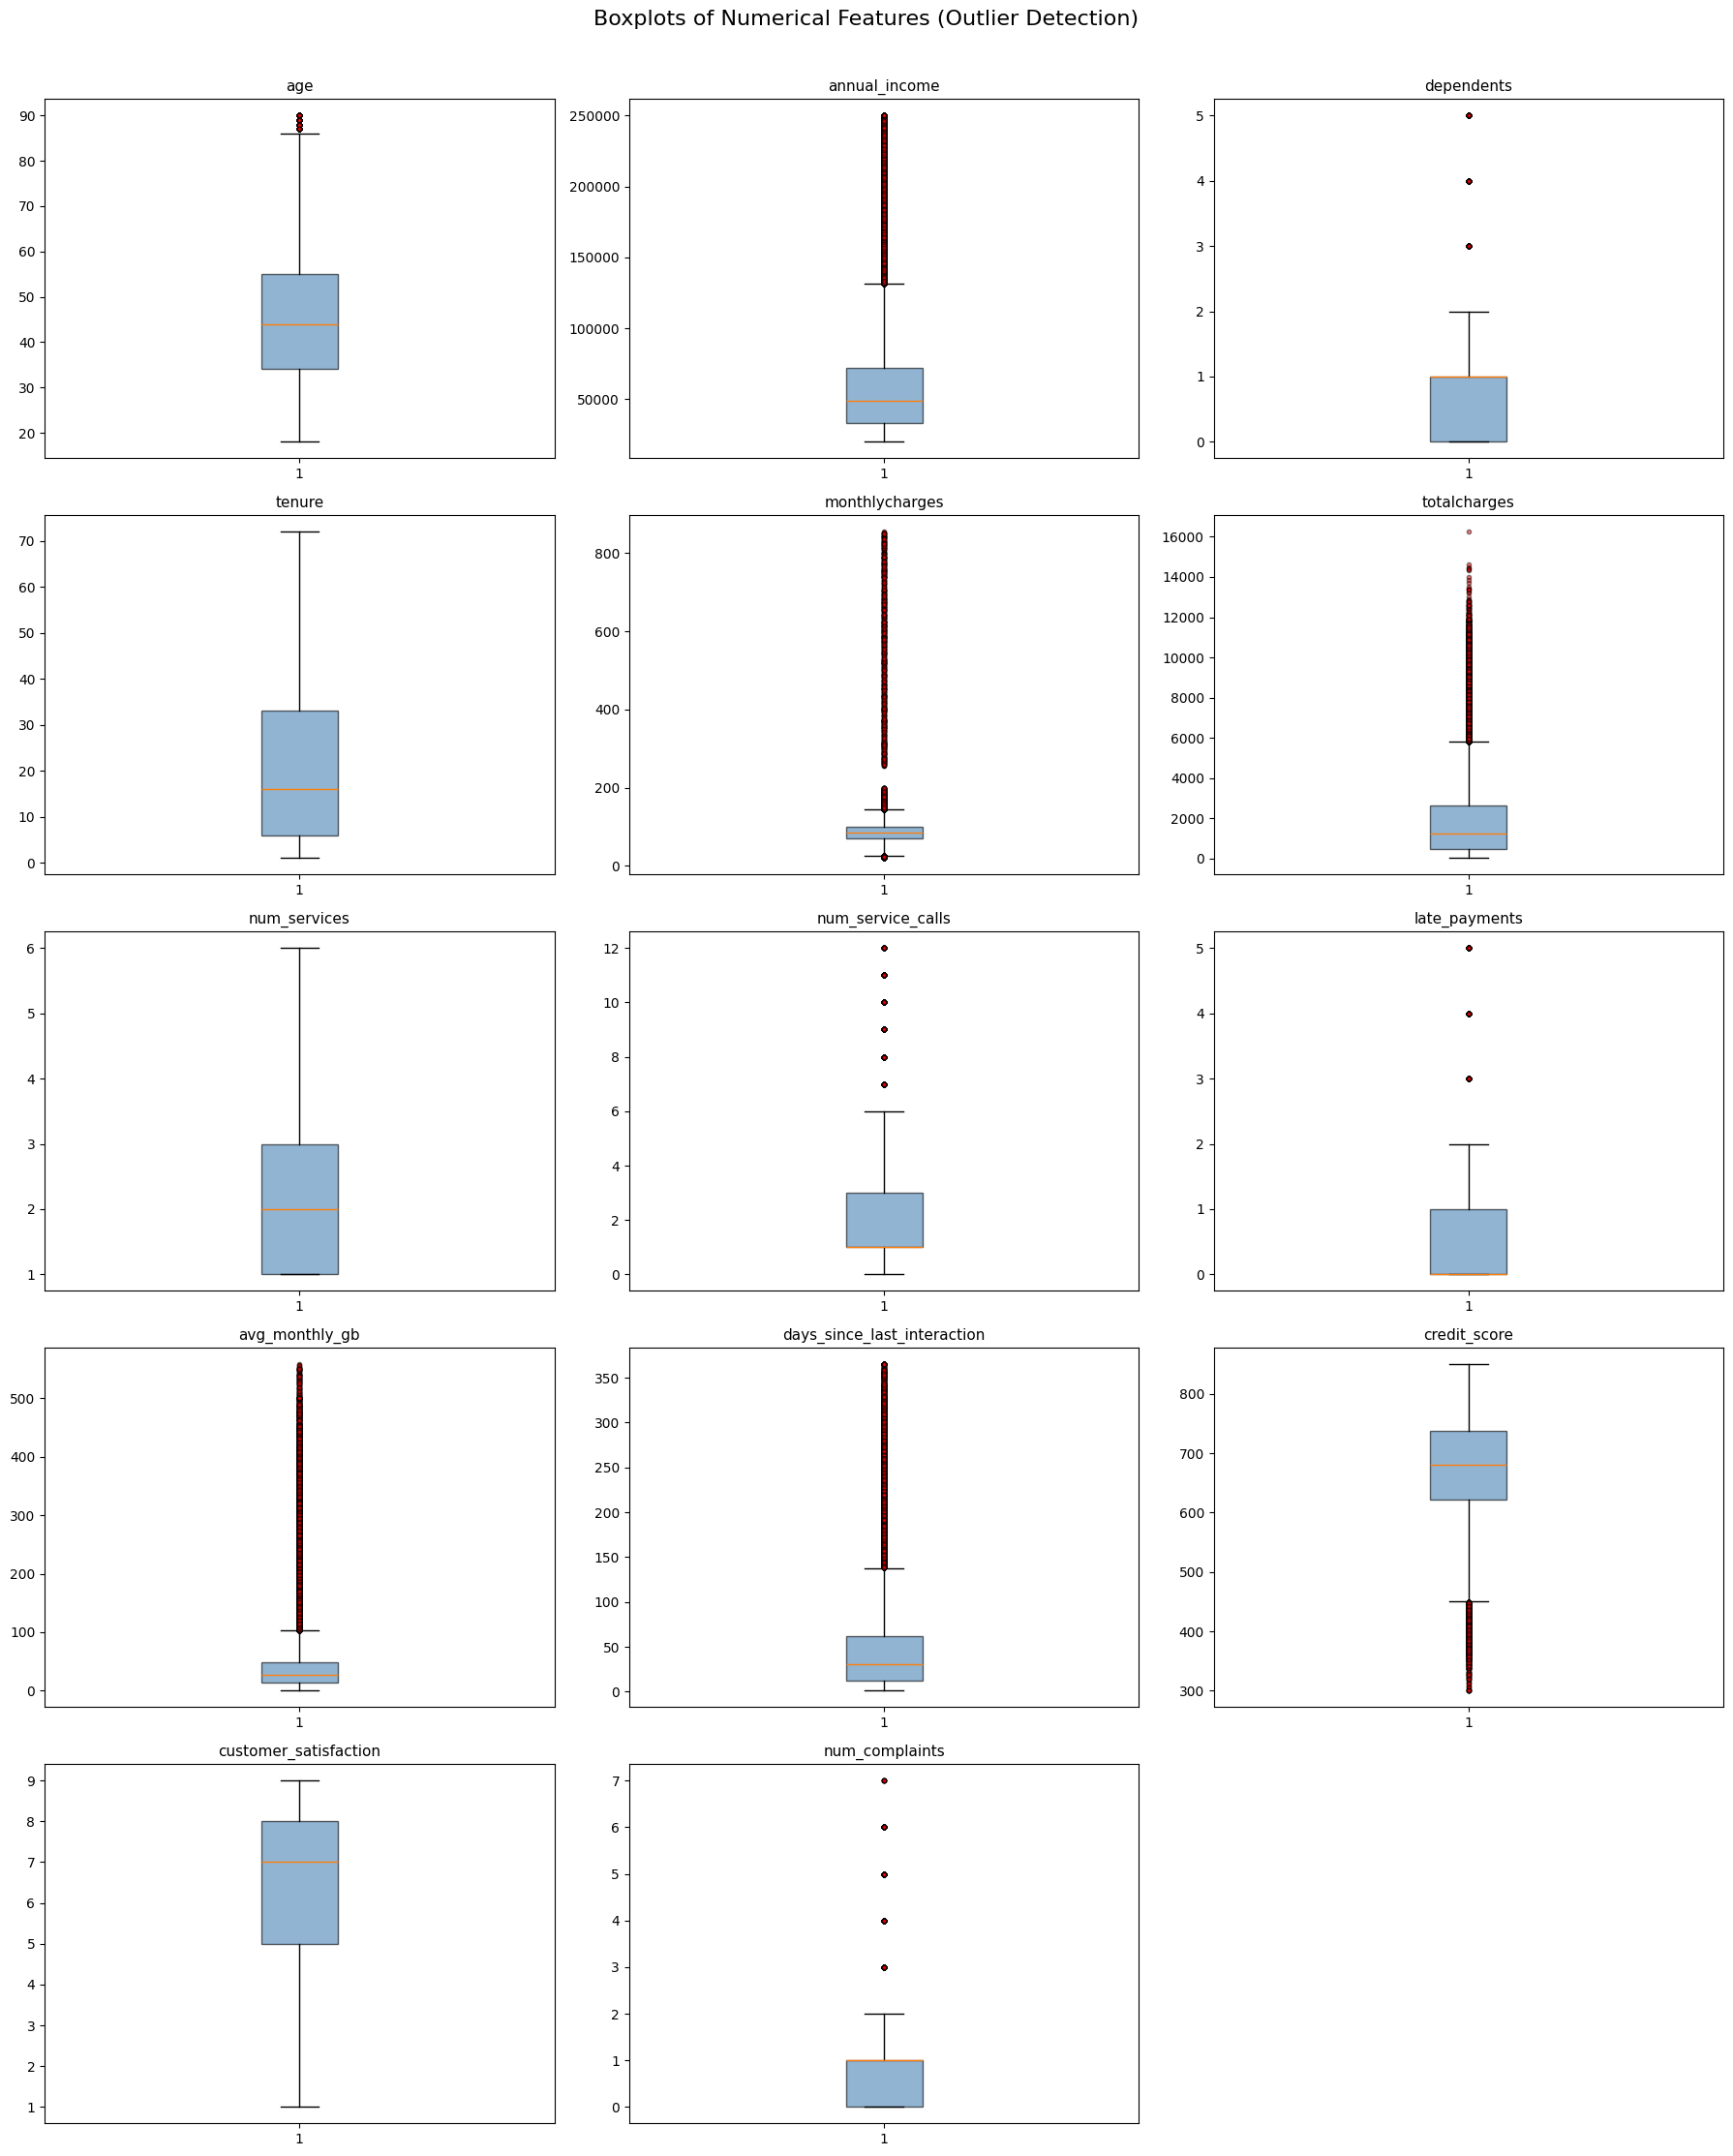

In [251]:
# Boxplots to visually identify outliers
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()
for i, col in enumerate(num_features):
    axes[i].boxplot(df1[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=11)
# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Boxplots of Numerical Features (Outlier Detection)', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


**Outlier Observations:**
- `monthlycharges`: Values above ~$200 are flagged by the boxplot but are plausible (premium plans). We will not remove them — they may be informative churn signals.
- `avg_monthly_gb`: Extreme values >300 GB exist but are real heavy-data users. Winsorizing at the 99th percentile is a reasonable compromise.
- `totalcharges`: The long tail is expected — it scales with tenure. No action needed.
- `num_service_calls`: Extreme values (>8) exist. Keep as-is — they could be strong churn predictors.

**Decision:** We will apply winsorization (capping at 1st and 99th percentile) to the three most skewed features: `avg_monthly_gb`, `monthlycharges`, and `totalcharges` to reduce the influence of extreme outliers on linear models, while preserving them for tree-based models.


### Univariate Analysis of Categorical Features in `df1`

We now examine each categorical feature's value distribution and cardinality. Features with too many categories or severe imbalance may need consolidation.


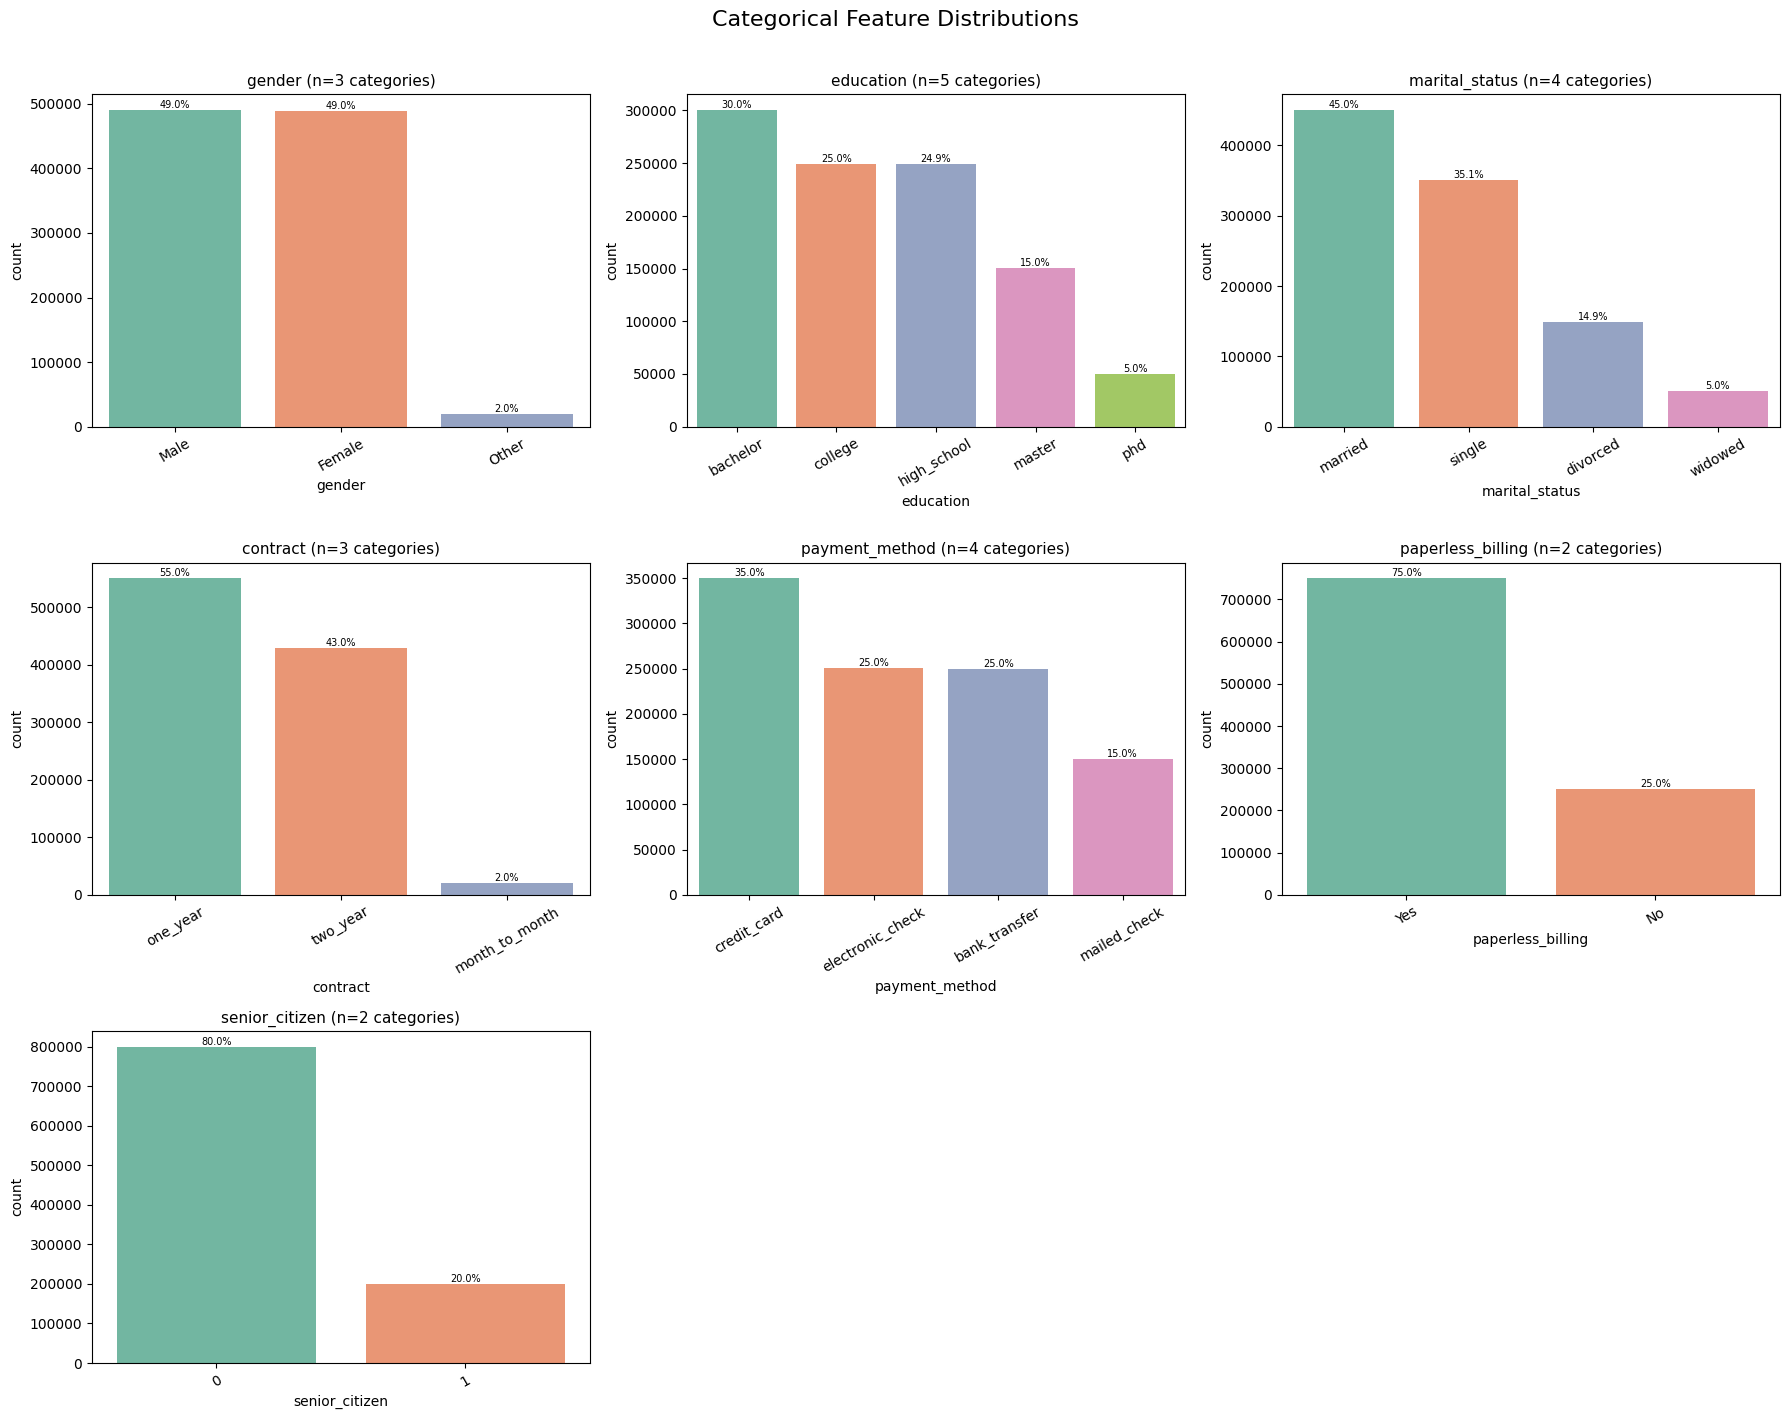

In [252]:
# Categorical features (excluding customer_id which is a unique identifier)
cat_features = ['gender', 'education', 'marital_status', 'contract',
                'payment_method', 'paperless_billing', 'senior_citizen']

# Count plots with percentage annotations
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
for i, col in enumerate(cat_features):
    order = df1[col].value_counts().index
    sns.countplot(data=df1, x=col, order=order, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} (n={df1[col].nunique()} categories)', fontsize=11)
    axes[i].tick_params(axis='x', rotation=30)
    total = len(df1)
    for p in axes[i].patches:
        pct = p.get_height() / total * 100
        axes[i].annotate(f'{pct:.1f}%', (p.get_x() + p.get_width() / 2, p.get_height()),
                         ha='center', va='bottom', fontsize=7)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
plt.suptitle('Categorical Feature Distributions', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


**Observations (Categorical):**
- **gender**: Near balanced — Male (49%), Female (~49%), Other (~2%). No dominance issue.
- **education**: Bachelor (30%) and College (~27%) are most common. PhD is rarest.
- **marital_status**: Married (~45%), Single (~25%), Divorced (~20%), Widowed (~10%) — reasonable spread.
- **contract**: One-year (55%) dominates, Two-year (~43%), Month-to-month (~2%). Month-to-month is rare but likely high-risk.
- **payment_method**: Credit card (35%), Electronic check (~27%), Mailed check (~20%), Bank transfer (~18%).
- **paperless_billing**: Yes (75%) vs No (25%) — notable imbalance but not severe.
- **senior_citizen**: No (80%) vs Yes (20%) — expected imbalance. Senior citizens are a minority segment worth special attention.

**Justification:** No categories need consolidation (no rare levels <1%). All categorical features will be one-hot encoded (with `drop_first=True` for k-1 encoding). `education` has a natural ordinal relationship, so it will be ordinal-encoded separately.
